# Comparative Analysis of Simple and Multiple Linear Regression Using Data Visualization and Exploratory Data Analysis

### Dataset: House Price Prediction
### Target Variable: Price

In [13]:
%pip install seaborn

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Loading the Dataset

In [3]:
df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## 3. Dataset Overview

In [15]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (4600, 18)

Columns:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [16]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [17]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 4. Data Preprocessing



In [19]:
df = df.drop_duplicates()
df = df.dropna()

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (4600, 18)


## 5. Exploratory Data Analysis (EDA)

### Distribution of House Prices

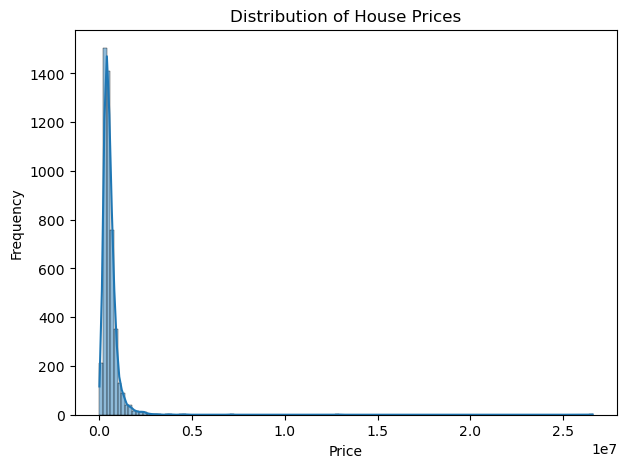

In [20]:
plt.figure(figsize=(7,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Area vs House Price

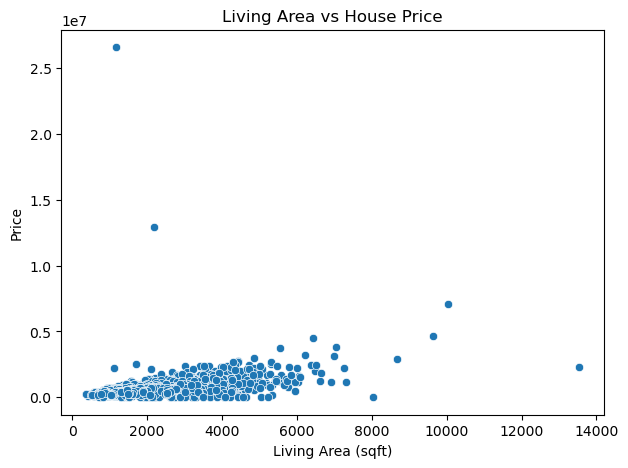

In [21]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["sqft_living"], y=df["price"])
plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.show()

### Correlation Heatmap

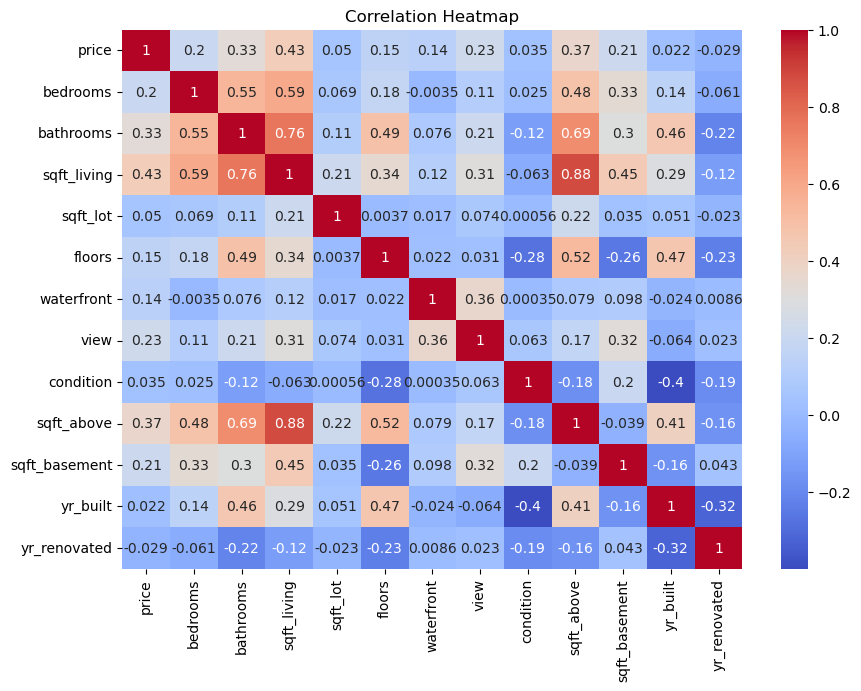

In [22]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### House Price Box Plot

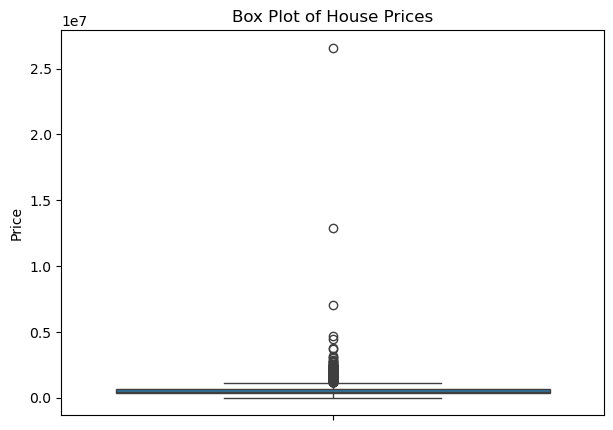

In [23]:
plt.figure(figsize=(7,5))
sns.boxplot(y=df["price"])
plt.title("Box Plot of House Prices")
plt.ylabel("Price")
plt.show()

## 6. Simple Linear Regression

Simple Linear Regression is performed using sqft_living as the independent variable and price as the dependent variable.

In [25]:
X = df[["sqft_living"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

slr = LinearRegression()
slr.fit(X_train, y_train)

y_pred_slr = slr.predict(X_test)

### Simple Linear Regression Line

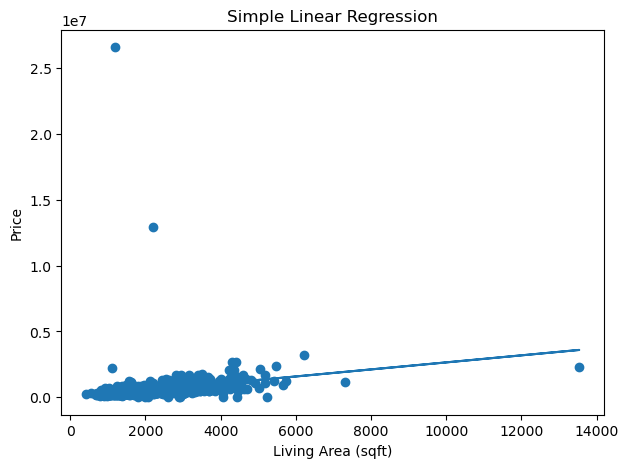

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_slr)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()

### Simple Linear Regression Evaluation

In [27]:
slr_r2 = r2_score(y_test, y_pred_slr)
slr_mae = mean_absolute_error(y_test, y_pred_slr)
slr_mse = mean_squared_error(y_test, y_pred_slr)
slr_rmse = np.sqrt(slr_mse)

print("R² Score:", slr_r2)
print("MAE:", slr_mae)
print("MSE:", slr_mse)
print("RMSE:", slr_rmse)

R² Score: 0.02906541034141008
MAE: 225375.25345857363
MSE: 990204087727.142
RMSE: 995089.9897633088


## 7. Multiple Linear Regression

Multiple Linear Regression is performed using multiple house characteristics to predict house price.

In [28]:
features = [
    "sqft_living",
    "bedrooms",
    "bathrooms",
    "floors",
    "condition"
]

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

### Multiple Linear Regression Evaluation

In [29]:
mlr_r2 = r2_score(y_test, y_pred_mlr)
mlr_mae = mean_absolute_error(y_test, y_pred_mlr)
mlr_mse = mean_squared_error(y_test, y_pred_mlr)
mlr_rmse = np.sqrt(mlr_mse)

print("R² Score:", mlr_r2)
print("MAE:", mlr_mae)
print("MSE:", mlr_mse)
print("RMSE:", mlr_rmse)

R² Score: 0.02929090464808959
MAE: 222208.42678777722
MSE: 989974118183.7645
RMSE: 994974.4309195913


### Actual vs Predicted House Prices

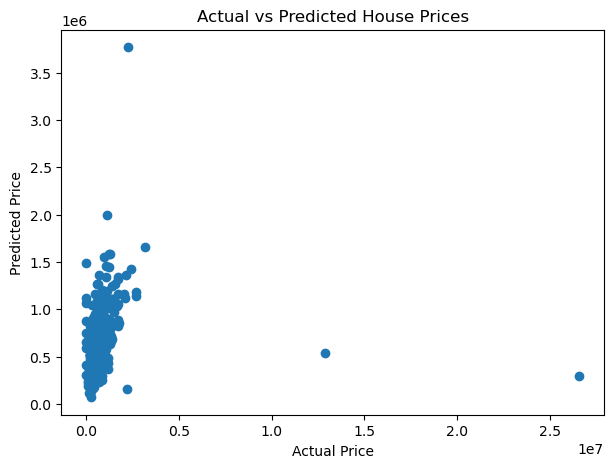

In [30]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## 8. Model Performance Comparison

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "R2 Score": [slr_r2, mlr_r2],
    "MAE": [slr_mae, mlr_mae],
    "MSE": [slr_mse, mlr_mse],
    "RMSE": [slr_rmse, mlr_rmse]
})

comparison

,Model,R2 Score,MAE,MSE,RMSE
0,Simple Linear Regression,0.029065,225375.253459,9.902041e+11,995089.989763
1,Multiple Linear Regression,0.029291,222208.426788,9.899741e+11,994974.430920


### R² Score Comparison

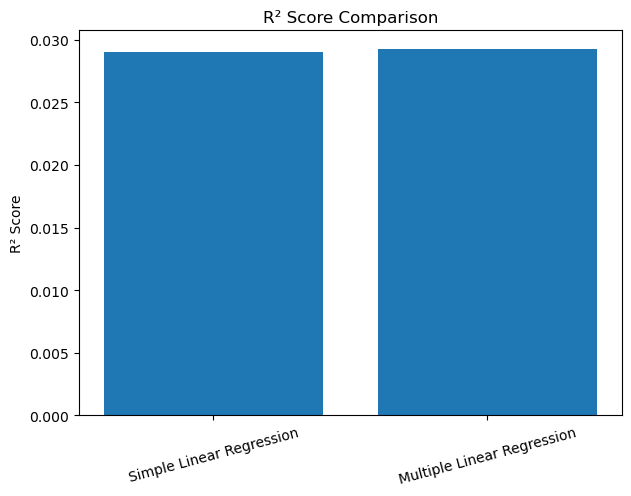

In [32]:
plt.figure(figsize=(7,5))
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.ylabel("R² Score")
plt.title("R² Score Comparison")
plt.xticks(rotation=15)
plt.show()

## 9. Comparative Analysis

In [33]:
if mlr_r2 > slr_r2:
    print("Multiple Linear Regression performed better.")
else:
    print("Simple Linear Regression performed better.")

Multiple Linear Regression performed better.


## 10. Key Findings

- The dataset contains 4600 house records and 18 variables.
- Price is selected as the target variable.
- sqft_living shows a strong relationship with house price.
- Simple Linear Regression uses only sqft_living for prediction.
- Multiple Linear Regression uses sqft_living, bedrooms, bathrooms, floors and condition.
- EDA helped identify relationships, distributions and possible outliers.
- Both models were evaluated using R² Score, MAE, MSE and RMSE.
- The model with higher R² and lower error values provides better prediction performance.